<a href="https://colab.research.google.com/github/SoumyaPannala/dsa405-project/blob/main/DSA405_002_FA26_P2_spannal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **P2: Data Audit, Cleaning Log, & Provenance Brief**
---


## **1. The Audit**

This is a systematic pass over the raw data, with output that shows each check.

At a minimum, for every column this analysis will use:

- dtype as loaded, and dtype as it should be (the dtype is the data type pandas assigned to the column)
- count and rate of missing values, dropna=False
- number of distinct values
- min, max, and range for anything numeric
- the full set of distinct values for anything categorical with under about 30 levels
- which classes of defect were checked for and not found. Sentinel values recorded as if they were real data (a sentinel is a special value, such as 999 or "N/A", written inside a data column to mean "no real value here"). Total or subtotal rows mixed in with the observations. Leading zeros in identifiers. Text garbled by reading the file with the wrong character encoding. Duplicate keys. Dates in more than one format. Numbers stored as text.

First, we'll import pandas and read in our data.

In [2]:
import pandas as pd

DATA = "https://raw.githubusercontent.com/SoumyaPannala/dsa405-project/main/data/raw/"
df = pd.read_csv(DATA + "austin_animal_center_intakes_raw.csv.gz")

To make sure it read in properly, we'll run `df.head().`

In [4]:
df.head()

,:id,:version,:created_at,:updated_at,animal_id,name,datetime,datetime2,found_location,intake_type,intake_condition,animal_type,sex_upon_intake,age_upon_intake,breed,color
0,row-5scy-j6d5-2y33,rv-sk96.v6wf_i8zk,2025-05-19T15:11:08.679Z,2025-05-19T15:11:08.679Z,A521520,Nina,2013-10-01T07:51:00.000,2013-10-01T07:51:00.000,Norht Ec in Austin (TX),Stray,Normal,Dog,Spayed Female,7 years,Border Terrier/Border Collie,White/Tan
1,row-kpt7~mbcv~uxgj,rv-s59m-rznv_2aut,2025-05-19T15:11:08.679Z,2025-05-19T15:11:08.679Z,A664235,NaN,2013-10-01T08:33:00.000,2013-10-01T08:33:00.000,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
2,row-nrmv~7qgv~tqjb,rv-inze-qpsm_9bu2,2025-05-19T15:11:08.679Z,2025-05-19T15:11:08.679Z,A664236,NaN,2013-10-01T08:33:00.000,2013-10-01T08:33:00.000,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
3,row-b36g-3dxp.q3k3,rv-pcmh_5x7u_cwnx,2025-05-19T15:11:08.679Z,2025-05-19T15:11:08.679Z,A664237,NaN,2013-10-01T08:33:00.000,2013-10-01T08:33:00.000,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
4,row-gwpa~iepp-4323,rv-hhrt.mwqb_fgq4,2025-05-19T15:11:08.679Z,2025-05-19T15:11:08.679Z,A664233,Stevie,2013-10-01T08:53:00.000,2013-10-01T08:53:00.000,7405 Springtime in Austin (TX),Stray,Injured,Dog,Intact Female,3 years,Pit Bull Mix,Blue/White


Running this will give us a summary of many aspects of our raw data before we make changes. Based on this, we might rerun some portions individually so we can expand upon them.

In [5]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nShape:")
print(df.shape)

Rows: 173812
Columns: 16

Columns:
[':id', ':version', ':created_at', ':updated_at', 'animal_id', 'name', 'datetime', 'datetime2', 'found_location', 'intake_type', 'intake_condition', 'animal_type', 'sex_upon_intake', 'age_upon_intake', 'breed', 'color']

Data types:
:id                 object
:version            object
:created_at         object
:updated_at         object
animal_id           object
name                object
datetime            object
datetime2           object
found_location      object
intake_type         object
intake_condition    object
animal_type         object
sex_upon_intake     object
age_upon_intake     object
breed               object
color               object
dtype: object

Shape:
(173812, 16)


Rerunning dtypes for all of these, we see that everything got read in as an object. However, not all should be.

In [6]:
print("Data types as loaded:")
print(df.dtypes)

Data types as loaded:
:id                 object
:version            object
:created_at         object
:updated_at         object
animal_id           object
name                object
datetime            object
datetime2           object
found_location      object
intake_type         object
intake_condition    object
animal_type         object
sex_upon_intake     object
age_upon_intake     object
breed               object
color               object
dtype: object


| Variable           | Loaded as | Should be | Reason                                                      |
| ------------------ | --------- | --------- | ----------------------------------------------------------- |
| `:id`              | object    | string    | Identifier; shouldn't be treated as numeric                 |
| `:version`         | object    | string    | Version/metadata identifier                                 |
| `:created_at`      | object    | datetime  | Timestamp                                                   |
| `:updated_at`      | object    | datetime  | Timestamp                                                   |
| `animal_id`        | object    | string    | Identifier; preserve its exact representation               |
| `name`             | object    | string    | Animal name                                                 |
| `datetime`         | object    | datetime  | Intake timestamp                                            |
| `datetime2`        | object    | datetime  | Second intake date/time representation                      |
| `found_location`   | object    | string    | Name of  location where the animal was found                                         |
| `intake_type`      | object    | category  | Small set of repeated intake types                          |
| `intake_condition` | object    | category  | Small set of repeated conditions                            |
| `animal_type`      | object    | category  | Small set of animal types                                   |
| `sex_upon_intake`  | object    | category  | Small set of repeated sex/neuter-status values              |
| `age_upon_intake`  | object    | string    | Values like `"2 years"` / `"3 months"` contain units        |
| `breed`            | object    | string    | categorical breed labels; potentially many levels |
| `color`            | object    | string    | Color descriptions; potentially many combinations           |

As we can see, many of these variables will need to be converted from object to other datatypes as we listed above. Before we get there, we'll check which columns are missing values and finish the rest of our audit.

In [8]:
# Missing values by column

missing_audit = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_rate": df.isna().mean() * 100,
    "total_rows": len(df)
})

missing_audit["missing_rate"] = missing_audit["missing_rate"].round(2)

missing_audit

,missing_count,missing_rate,total_rows
:id,0,0.00,173812
:version,0,0.00,173812
:created_at,0,0.00,173812
:updated_at,0,0.00,173812
animal_id,0,0.00,173812
name,49991,28.76,173812
datetime,0,0.00,173812
datetime2,0,0.00,173812
found_location,0,0.00,173812
intake_type,0,0.00,173812


`name` and `sex_upon_intake` are the two variables missing data explicitly, though there could be others coded with sentinels that are not flagged as missing but represent missing data. Of the two we have found explicitly so far though, `name` has the most missing values but for our particular analysis, name might not be so important.

Now let's look at how many unique values are in each column, making sure to account for missing values.

In [9]:
# Number of distinct values in each column, including missing values

distinct_audit = pd.DataFrame({
    "distinct_values": [
        df[col].nunique(dropna=False)
        for col in df.columns
    ]
}, index=df.columns)

distinct_audit

,distinct_values
:id,173812
:version,173812
:created_at,1
:updated_at,1
animal_id,156287
name,29775
datetime,119722
datetime2,119722
found_location,70183
intake_type,6


In [26]:
# Full set of distinct values for categorical variables with under 30 levels

categorical_cols = [
    "intake_type",
    "intake_condition",
    "animal_type",
    "sex_upon_intake",
    "age_upon_intake"
]

for col in categorical_cols:
    print(f"\n{'=' * 60}")
    print(f"\n--- {col} ---")
    print(f"Unique values: {df[col].nunique(dropna=False)}")
    print(df[col].value_counts(dropna=False))



--- intake_type ---
Unique values: 6
intake_type
Stray                 119160
Owner Surrender        35563
Public Assist          10432
Wildlife                6483
Abandoned               1910
Euthanasia Request       264
Name: count, dtype: int64


--- intake_condition ---
Unique values: 20
intake_condition
Normal        147141
Injured        10805
Sick            7939
Nursing         3878
Neonatal        1971
Medical          614
Aged             525
Other            353
Pregnant         170
Feral            145
Med Attn          87
Behavior          81
Unknown           48
Med Urgent        21
Neurologic        13
Parvo             11
Agonal             4
Space              4
Panleuk            1
Congenital         1
Name: count, dtype: int64


--- animal_type ---
Unique values: 5
animal_type
Dog          94608
Cat          69324
Other         8968
Bird           878
Livestock       34
Name: count, dtype: int64


--- sex_upon_intake ---
Unique values: 6
sex_upon_intake
Intact Mal

The most frequent categories for each of the four variables above are `Stray`, `Normal`, `Dog` and `Intact Male`.

There are currently no numeric dtypes in this dataset. Since no variables were loaded in as numeric data types, min, max, or range calculations aren't applicable to the raw dataset. Numeric-looking values were also not found in any variable expected to represent a numeric measurement. The only exception to this would be age but that will be revisited a little later as it has varying units (sometimes months and sometimes years) and it includes both the numeric value as well as the units in text all as part of the variable.

In [28]:
print("ALL AGE VALUES:")
print(df["age_upon_intake"].value_counts(dropna=False).sort_index())

ALL AGE VALUES:
age_upon_intake
-1 years         6
-2 years         1
-3 years         2
-4 years         1
0 years       1268
1 day         1018
1 month      18203
1 week        1483
1 weeks       1433
1 year       28294
10 months     1388
10 years      2292
11 months     1140
11 years       925
12 years      1116
13 years       717
14 years       525
15 years       453
16 years       193
17 years       104
18 years        62
19 years        29
2 days         771
2 months     10432
2 weeks       3655
2 years      28033
20 years        26
21 years         1
22 years         6
23 years         1
24 years         1
25 years         2
28 years         1
3 days         920
3 months      4924
3 weeks       5124
3 years       9610
30 years         1
4 days         501
4 months      4787
4 weeks       6324
4 years       5842
5 days         265
5 months      4377
5 weeks        444
5 years       5187
6 days         538
6 months      3329
6 years       3426
7 months      2591
7 years       3010

Sorting in this way brings the negative values, which we'll need to handle, to the the top so we can clearly see what needs fixing. Before we move on, let's also see if there are any others that we can print unique categories for.

In [32]:
print("ANIMAL ID")
print("Unique animal IDs:", df["animal_id"].nunique())
print("Missing animal IDs:", df["animal_id"].isna().sum())

print("\n" + "=" * 60)
print("NAME")
print("Missing:", df["name"].isna().sum())
print("Blank:", (df["name"].fillna("").str.strip() == "").sum())

print("\n" + "=" * 60)
print("BREED")
print("Unique:", df["breed"].nunique())
print("Missing:", df["breed"].isna().sum())
print("Sample:")
print(df["breed"].value_counts().head(20))

print("\n" + "=" * 60)
print("COLOR")
print("Unique:", df["color"].nunique())
print("Missing:", df["color"].isna().sum())
print("Sample:")
print(df["color"].value_counts().head(20))

print("\n" + "=" * 60)
print("FOUND LOCATION")
print("Missing:", df["found_location"].isna().sum())
print("Unique:", df["found_location"].nunique())

ANIMAL ID
Unique animal IDs: 156287
Missing animal IDs: 0

NAME
Missing: 49991
Blank: 49991

BREED
Unique: 3006
Missing: 0
Sample:
breed
Domestic Shorthair Mix       33665
Domestic Shorthair           24187
Pit Bull Mix                 10092
Labrador Retriever Mix        8808
Chihuahua Shorthair Mix       6889
German Shepherd Mix           4054
Pit Bull                      3490
Domestic Medium Hair Mix      3334
Bat                           2356
Domestic Medium Hair          2117
Labrador Retriever            2044
Chihuahua Shorthair           2014
Australian Cattle Dog Mix     1982
German Shepherd               1845
Bat Mix                       1756
Domestic Longhair Mix         1678
Siamese Mix                   1471
Boxer Mix                     1197
Dachshund Mix                 1186
Border Collie Mix             1149
Name: count, dtype: int64

COLOR
Unique: 661
Missing: 0
Sample:
color
Black/White          17976
Black                14651
Brown Tabby          10725
Brown       

**Now, we'll do all of our defect checks.**

In [15]:
sentinel_candidates = [
    "N/A", "NA", "n/a", "na", "NAN"
    "NULL", "null", "None", "none",
    "-", "?",
    "999", "9999",
    "Missing", "missing"
]

sentinel_audit = []

for col in df.select_dtypes(include="object").columns:
    counts = df[col].value_counts(dropna=False)

    for value in sentinel_candidates:
        if value in counts.index:
            sentinel_audit.append([col, value, counts[value]])

sentinel_audit = pd.DataFrame(
    sentinel_audit,
    columns=["column", "candidate", "count"]
)

sentinel_audit

,column,candidate,count
0,name,999,1


**Sentinel values:** Common sentinel candidates were checked across object columns. Only one candidate was found: "999" in name (1 record). Because it occurs in the name field, it was not automatically classified as missing without additional evidence.

In [14]:
for col in ["animal_id", "animal_type", "intake_type", "name"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(20))


--- animal_id ---
animal_id
A721033    33
A718223    14
A718877    12
A705625    12
A706536    11
A761266    10
A616444     9
A717053     9
A716018     9
A737814     9
A700407     9
A738324     8
A759467     8
A670937     8
A754989     8
A670612     8
A737833     8
A615920     8
A820013     8
A694501     8
Name: count, dtype: int64

--- animal_type ---
animal_type
Dog          94608
Cat          69324
Other         8968
Bird           878
Livestock       34
Name: count, dtype: int64

--- intake_type ---
intake_type
Stray                 119160
Owner Surrender        35563
Public Assist          10432
Wildlife                6483
Abandoned               1910
Euthanasia Request       264
Name: count, dtype: int64

--- name ---
name
NaN         49991
Luna          761
Max           725
Bella         676
Rocky         490
Daisy         466
Coco          432
Charlie       411
Princess      407
Blue          394
Buddy         389
Lucy          379
Lola          357
Zeus          321
Oreo   

**Total/subtotal rows:** Checked identifying and categorical fields for aggregate-style records. No total, subtotal, grand total, or other non-animal aggregate rows were identified. In other words, everything is normal here.

In [16]:
for col in [":id", ":version", "animal_id"]:
    print(f"\n--- {col} ---")
    print("First 10 values:")
    print(df[col].head(10).tolist())

    print("Values starting with 0:")
    print(df[col].astype(str).str.startswith("0").sum())

    print("Values containing only digits:")
    print(df[col].astype(str).str.fullmatch(r"\d+").sum())


--- :id ---
First 10 values:
['row-5scy-j6d5-2y33', 'row-kpt7~mbcv~uxgj', 'row-nrmv~7qgv~tqjb', 'row-b36g-3dxp.q3k3', 'row-gwpa~iepp-4323', 'row-dxin_ebe2.6h8g', 'row-38uf~p2jf-cjsi', 'row-q3p5-z4br~m2j7', 'row-w9yy~tk2h_7s57', 'row-rzac-iv55~ma37']
Values starting with 0:
0
Values containing only digits:
0

--- :version ---
First 10 values:
['rv-sk96.v6wf_i8zk', 'rv-s59m-rznv_2aut', 'rv-inze-qpsm_9bu2', 'rv-pcmh_5x7u_cwnx', 'rv-hhrt.mwqb_fgq4', 'rv-r4h7~663p-uf8v', 'rv-jg3a-2sxx~tv4q', 'rv-u4pt~hh22_h8cw', 'rv-359p_rwzg.th7j', 'rv-sj38-k2mh-rccx']
Values starting with 0:
0
Values containing only digits:
0

--- animal_id ---
First 10 values:
['A521520', 'A664235', 'A664236', 'A664237', 'A664233', 'A664238', 'A664234', 'A664256', 'A664257', 'A664266']
Values starting with 0:
0
Values containing only digits:
0


**Finding**
- `:id` uses IDs beginning with `row-`, followed by an alphanumeric identifier. No values begin with `0`.
- `:version` uses IDs beginning with `rv-`, followed by an alphanumeric identifier. No values begin with `0`.
- `animal_id` uses the pattern `A######` (for example, `A521520`). No values begin with `0`.
- None of the three identifier columns consist entirely of digits, so there isn't evidence that leading zeros are being lost because identifiers were interpreted as numbers.

**One Line Summary**
- **Leading zeros in identifiers:** Checked `:id`, `:version`, and `animal_id`. All three are stored as objects and retain their observed alphanumeric formats. No values begin with `0`, and so there is nothing to suggest that we lost leading zeros when we read in the data.

Now let's check for encoding characters that could be mixed in if the data didn't read in right.

In [17]:
encoding_candidates = ["Ã", "Â", "â", "�"]

encoding_audit = []

for col in df.select_dtypes(include="object").columns:
    for pattern in encoding_candidates:
        count = df[col].astype("string").str.contains(pattern, regex=False, na=False).sum()
        if count > 0:
            encoding_audit.append([col, pattern, count])

encoding_audit = pd.DataFrame(
    encoding_audit,
    columns=["column", "artifact", "count"]
)

encoding_audit

,column,artifact,count


Since we got back an empty table, this means that none of these unwanted characters that we checked for were found.

**Duplicate keys**

Before we check for duplicates, we must remember that...

- `animal_id` is not supposed to be unique because the same animal can have multiple intake records.
- We still should check that `:id` is unique, though I doubt we'll use this column
- We should also check for completely identical rows as those would be a problem

In [34]:
id_counts = df["animal_id"].value_counts()

print("Total intake records:", len(df))
print("Unique animals:", df["animal_id"].nunique())
print("Animals with multiple intake records:", (id_counts > 1).sum())
print("Maximum intake records for one animal:", id_counts.max())

print("\nMost frequent animal IDs:")
print(id_counts.head(10))

Total intake records: 173812
Unique animals: 156287
Animals with multiple intake records: 13487
Maximum intake records for one animal: 33

Most frequent animal IDs:
animal_id
A721033    33
A718223    14
A718877    12
A705625    12
A706536    11
A761266    10
A616444     9
A717053     9
A716018     9
A737814     9
Name: count, dtype: int64


In [18]:
print(":id unique:", df[":id"].is_unique)
print(":id duplicate count:", df[":id"].duplicated().sum())

print("\nExact duplicate rows:", df.duplicated().sum())

:id unique: True
:id duplicate count: 0

Exact duplicate rows: 0


**Duplicate keys finding**
- `:id` is unique across all `173,812` rows.
- `:id` has `0` duplicate values.
- There are `0` exact duplicate rows.
- `animal_id` is intentionally not unique because animals can have multiple intake records.

**Duplicate keys one liner:**
- `:id` was confirmed to be unique across all records, with `0` duplicate values. No exact duplicate rows were identified. `animal_id` is not unique, consistent with the fact that there can be multiple intake records potentially belonging to the same animal. No cleaning needed here either.

In [20]:
date_pattern_audit = {}

for col in [":created_at", ":updated_at", "datetime", "datetime2"]:
    if col in [":created_at", ":updated_at"]:
        pattern = r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}Z$"
    else:
        pattern = r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{3}$"

    date_pattern_audit[col] = df[col].astype("string").str.fullmatch(
        pattern, na=False
    ).sum()

date_pattern_audit

{':created_at': np.int64(173812),
 ':updated_at': np.int64(173812),
 'datetime': np.int64(173812),
 'datetime2': np.int64(173812)}

**Dates in Multiple Formats:** The four date/time columns (`:created_at`, `:updated_at`, `datetime`, and `datetime2`) were checked for inconsistent formatting across all `173,812` records. Every value in each column followed the same format as the other values in that column. Each column was compared against its expected date pattern across all `173,812` records. All `173,812` values in each column matched the expected pattern. No dates were found using a different format within any of the four columns.

In [30]:
print("\n" + "=" * 60)
print("DATETIME SAMPLE:")
print(df["datetime"].head(10).to_string(index=False))

print("\nDATETIME2 SAMPLE:")
print(df["datetime2"].head(10).to_string(index=False))

print("\nDATE RANGE:")
print("datetime:", df["datetime"].min(), "to", df["datetime"].max())
print("datetime2:", df["datetime2"].min(), "to", df["datetime2"].max())


DATETIME SAMPLE:
2013-10-01T07:51:00.000
2013-10-01T08:33:00.000
2013-10-01T08:33:00.000
2013-10-01T08:33:00.000
2013-10-01T08:53:00.000
2013-10-01T09:33:00.000
2013-10-01T10:37:00.000
2013-10-01T10:59:00.000
2013-10-01T11:01:00.000
2013-10-01T11:09:00.000

DATETIME2 SAMPLE:
2013-10-01T07:51:00.000
2013-10-01T08:33:00.000
2013-10-01T08:33:00.000
2013-10-01T08:33:00.000
2013-10-01T08:53:00.000
2013-10-01T09:33:00.000
2013-10-01T10:37:00.000
2013-10-01T10:59:00.000
2013-10-01T11:01:00.000
2013-10-01T11:09:00.000

DATE RANGE:
datetime: 2013-10-01T07:51:00.000 to 2025-05-04T23:44:00.000
datetime2: 2013-10-01T07:51:00.000 to 2025-05-04T23:44:00.000


This allows us to see the range we have for both date variables. Next let's look at which columns have numbers interpretted as text and ensure nothing is unintended.

In [21]:
for col in df.columns:
    numeric_count = pd.to_numeric(df[col], errors="coerce").notna().sum()

    if numeric_count > 0:
        print(f"{col}: {numeric_count:,} values can be interpreted as numbers")

name: 256 values can be interpreted as numbers


**Numbers Stored as Text:** The raw dataset contains no columns that are expected to be numeric, so there were no numeric variables to convert or correct. A check for numeric-looking values found `256` such values in the name column, but this column is a text field. No numbers-stored-as-text issue was identified.

## **2. The Data Dictionary**
This will have at least five variables, and every variable used in the analysis.

| Variable name | Type | Units | Factor levels | Valid range | Missingness | Notes |
|---|---|---|---|---|---|---|
| `:id` | string | none | — | Alphanumeric row identifier | 0 (0%); no missing values | Unique row identifier; confirmed unique across all 173,812 records. |
| `:version` | string | none | — | Alphanumeric version identifier | 0 (0%); no missing values | Dataset/version identifier; should remain text rather than being treated as a number. |
| `:created_at` | date | timestamp | — | Valid date/time | 0 (0%); no missing values | Dataset metadata timestamp. All observed values use the same format. |
| `:updated_at` | date | timestamp | — | Valid date/time | 0 (0%); no missing values | Dataset metadata timestamp. All observed values use the same format. |
| `animal_id` | string | none | — | Identifier beginning with `A` followed by digits | 0 (0%); no missing values | Identifies an animal but is not unique because an animal can have multiple intake records. |
| `name` | string | none | — | Text name; may be missing | 49,991 (28.76%); missing means no animal name was recorded | Missing names do not make the intake record invalid. One record contains `"999"`; this was flagged but not automatically treated as missing. |
| `datetime` | date | timestamp | — | Valid date/time: 2013-10-01T07:51:00.000 to 2025-05-04T23:44:00.000 | 0 (0%); no missing values | Intake date and time. All observed values use the same format. |
| `datetime2` | date | timestamp | — | Valid date/time: 2013-10-01T07:51:00.000 to 2025-05-04T23:44:00.000 | 0 (0%); no missing values | Alternate intake date-time field; has the same number of distinct values as `datetime`. |
| `found_location` | string | none | — | Text description of location | 0 (0%); no missing values | Location where the animal was found or received. |
| `intake_type` | category | none | Stray; Owner Surrender; Public Assist; Wildlife; Abandoned; Euthanasia Request | One of the listed factor levels | 0 (0%); no missing values | Describes how the animal entered the shelter. |
| `intake_condition` | category | none | Normal; Injured; Sick; Nursing; Neonatal; Medical; Aged; Other; Pregnant; Feral; Med Attn; Behavior; Unknown; Med Urgent; Neurologic; Parvo; Agonal; Space; Panleuk; Congenital | One of the listed factor levels | 0 (0%); no missing values | Describes the animal's recorded condition at intake. |
| `animal_type` | category | none | Dog; Cat; Other; Bird; Livestock | One of the listed factor levels | 0 (0%); no missing values | Animal type recorded at intake. |
| `sex_upon_intake` | category | none | Intact Male; Intact Female; Neutered Male; Spayed Female; Unknown | One of the listed factor levels or missing | 1 (0.00%); missing means sex information was not recorded | `Unknown` is a legitimate recorded category, not automatically treated as missing. |
| `age_upon_intake` | string | days, weeks, months, or years | — | Nonnegative age expressed as a number plus an age unit. Negative ages assumed to represent missing or unknown or best guesses of age when unable to be accurately determined | 0 (0%); no missing values | Stored as text because values include both numbers and units. |
| `breed` | string | none | — | Text description of breed | 0 (0%); no missing values | May contain breed combinations or descriptive breed information. |
| `color` | string | none | — | Text description of animal color | 0 (0%); no missing values | May contain multiple colors or descriptive color combinations. |

Documentation check: The available source documentation does not specify additional required ranges or factor levels for these variables, and I didn't find any contradictions between the documented values and the observed data.

## **3. The Cleaning Log**

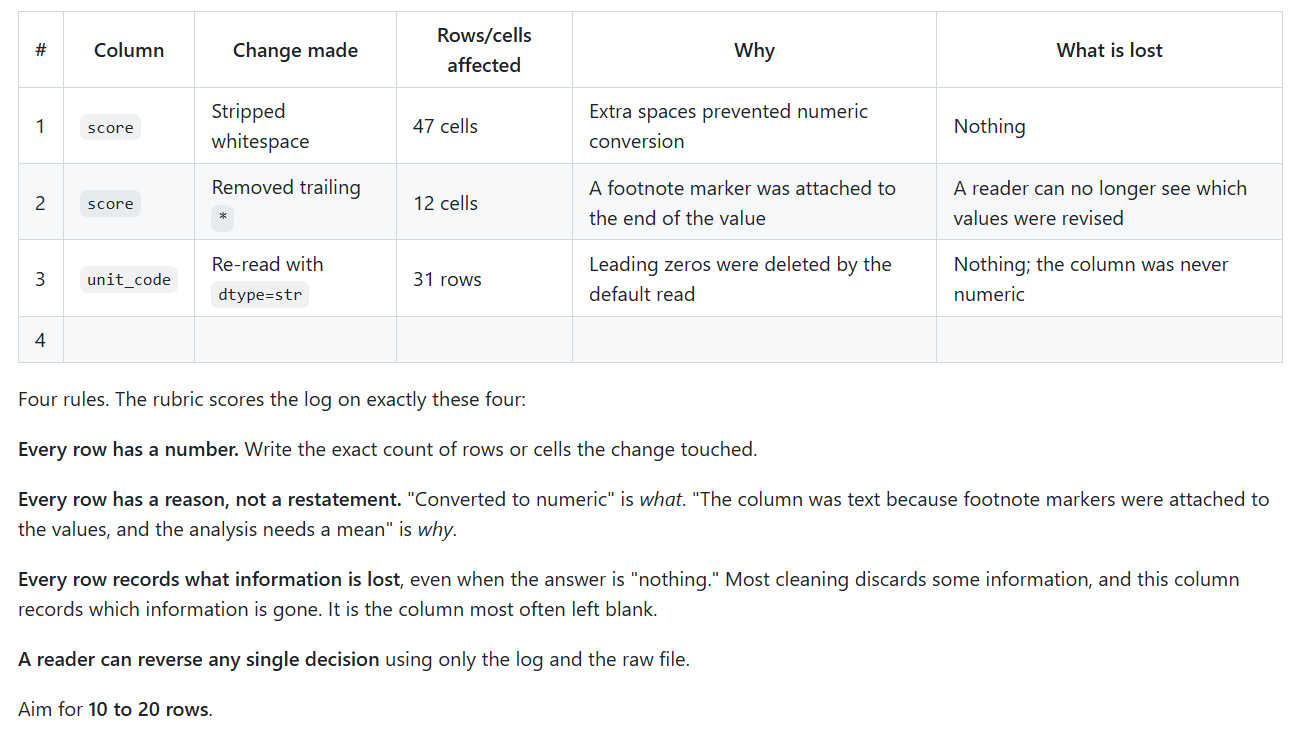

First let's look at the records that had negative ages to see if we can find any patterns or possible reasons for the negative numbering they used.

In [35]:
negative_age = df[
    df["age_upon_intake"].str.match(r"^-\d+ years$")
]

print(negative_age[
    [
        "animal_id",
        "datetime",
        "animal_type",
        "sex_upon_intake",
        "age_upon_intake",
        "breed",
        "color",
        "intake_condition"
    ]
].to_string(index=False))

animal_id                datetime animal_type sex_upon_intake age_upon_intake                   breed               color intake_condition
  A753893 2015-06-26T16:30:00.000         Dog     Intact Male        -1 years    American Bulldog Mix         White/Brown           Normal
  A725472 2016-06-12T14:16:00.000         Dog   Neutered Male        -3 years Chihuahua Shorthair Mix         White/Brown             Aged
  A757376 2017-09-01T16:49:00.000         Dog   Intact Female        -2 years Miniature Schnauzer Mix               White           Normal
  A725472 2018-07-10T16:25:00.000         Dog   Neutered Male        -1 years Chihuahua Shorthair Mix         White/Brown           Normal
  A757376 2018-10-13T13:42:00.000         Dog   Spayed Female        -1 years Miniature Schnauzer Mix               White           Normal
  A783723 2018-11-05T11:00:00.000         Cat   Intact Female        -4 years      Domestic Shorthair        White/Orange           Normal
  A725472 2019-02-26T11:25:

Similarly, let's look at the missing record for sex to see what might have happened.

In [48]:
print("MISSING SEX RECORD:")
print(
    df[df["sex_upon_intake"].isna()][
        [
            "animal_id",
            "datetime",
            "animal_type",
            "age_upon_intake",
            "breed",
            "color"
        ]
    ].to_string(index=False)
)

MISSING SEX RECORD:
animal_id                datetime animal_type age_upon_intake     breed       color
  A667395 2013-11-17T13:15:00.000         Dog         7 years Dachshund Brown Merle


Let's also compare datetime and datetime2 to see what the difference is between them if there is any.

In [49]:
print("\n" + "=" * 60)

print("DATETIME VS DATETIME2")
same_datetime = df["datetime"].eq(df["datetime2"])

print("Rows where they match:", same_datetime.sum())
print("Rows where they differ:", (~same_datetime).sum())


DATETIME VS DATETIME2
Rows where they match: 173812
Rows where they differ: 0


Now we can start cleaning our data based on what we noticed through the audit and all the earlier steps.

In [38]:
import numpy as np
import re

# Start from the raw data
intakes_clean = df.copy()

# 1. Remove Socrata metadata columns
metadata_cols = [":id", ":version", ":created_at", ":updated_at"]
intakes_clean = intakes_clean.drop(columns=metadata_cols)

# 2. Remove redundant datetime2 column
intakes_clean = intakes_clean.drop(columns=["datetime2"])

# 3. Standardize the singular/plural age inconsistency
intakes_clean["age_upon_intake"] = intakes_clean["age_upon_intake"].replace(
    {"1 weeks": "1 week"}
)

# 4. Replace impossible negative ages with missing
negative_age_mask = intakes_clean["age_upon_intake"].str.match(
    r"^-\d+ years$",
    na=False
)
intakes_clean.loc[negative_age_mask, "age_upon_intake"] = np.nan

print("Cleaned shape:", intakes_clean.shape)
print("Negative ages remaining:",
      intakes_clean["age_upon_intake"].str.match(
          r"^-\d+ years$", na=False
      ).sum())
print("Missing ages:", intakes_clean["age_upon_intake"].isna().sum())
print("Missing sex:", intakes_clean["sex_upon_intake"].isna().sum())

Cleaned shape: (173812, 11)
Negative ages remaining: 0
Missing ages: 10
Missing sex: 1


We should also represent ages in one consistent unit rather than mixing days, weeks, months, and years all in the same column. Converting them all to one unit will remove the need to have the units as part of each entry and we can treat this variable as numeric after this change.

In [39]:
def age_to_years(value):
    if pd.isna(value):
        return np.nan

    number, unit = value.split()
    number = float(number)

    if unit.startswith("day"):
        return number / 365.25
    elif unit.startswith("week"):
        return number * 7 / 365.25
    elif unit.startswith("month"):
        return number / 12
    elif unit.startswith("year"):
        return number
    else:
        return np.nan


intakes_clean["age_years"] = intakes_clean["age_upon_intake"].apply(age_to_years)

print(intakes_clean[["age_upon_intake", "age_years"]].head(20).to_string(index=False))

print("\nMissing age_years:", intakes_clean["age_years"].isna().sum())
print("Columns:", len(intakes_clean.columns))
print("Shape:", intakes_clean.shape)

age_upon_intake  age_years
        7 years   7.000000
         1 week   0.019165
         1 week   0.019165
         1 week   0.019165
        3 years   3.000000
       4 months   0.333333
        8 years   8.000000
       17 years  17.000000
        4 years   4.000000
         1 year   1.000000
        7 years   7.000000
         1 year   1.000000
        3 weeks   0.057495
        3 weeks   0.057495
        6 years   6.000000
        5 years   5.000000
        2 years   2.000000
         1 week   0.019165
         1 week   0.019165
       2 months   0.166667

Missing age_years: 10
Columns: 12
Shape: (173812, 12)


Let's check that all our cleaning steps went alright and nothing happened that we didn't expect or didn't intend.

In [45]:
print("=== POST-CLEANING AUDIT ===")

print("\nSHAPE:")
print(intakes_clean.shape)

print("\nCOLUMN NAMES:")
print(intakes_clean.columns.tolist())

print("\nDATA TYPES:")
print(intakes_clean.dtypes)

print("\nMISSING VALUES:")
print(intakes_clean.isna().sum())

print("\nRAW EXACT DUPLICATE ROWS:")
print(df.duplicated().sum())

print("\nDUPLICATES AFTER ANALYTICAL COLUMNS ONLY:")
print(intakes_clean.duplicated().sum())

print("\nAGE VALUES AFTER CLEANING:")
print(intakes_clean["age_upon_intake"].value_counts(dropna=False).sort_index())

print("\nNEGATIVE AGES REMAINING:")
print(
    intakes_clean["age_upon_intake"]
    .str.match(r"^-\d+ years$", na=False)
    .sum()
)

print("\nDATETIME AGREEMENT CHECK:")
print(
    "datetime and datetime2 were identical for all raw rows:",
    (df["datetime"] == df["datetime2"]).all()
)

=== POST-CLEANING AUDIT ===

SHAPE:
(173812, 12)

COLUMN NAMES:
['animal_id', 'name', 'datetime', 'found_location', 'intake_type', 'intake_condition', 'animal_type', 'sex_upon_intake', 'age_upon_intake', 'breed', 'color', 'age_years']

DATA TYPES:
animal_id            object
name                 object
datetime             object
found_location       object
intake_type          object
intake_condition     object
animal_type          object
sex_upon_intake      object
age_upon_intake      object
breed                object
color                object
age_years           float64
dtype: object

MISSING VALUES:
animal_id               0
name                49991
datetime                0
found_location          0
intake_type             0
intake_condition        0
animal_type             0
sex_upon_intake         1
age_upon_intake        10
breed                   0
color                   0
age_years              10
dtype: int64

RAW EXACT DUPLICATE ROWS:
0

DUPLICATES AFTER ANALYTICAL CO

In [42]:
# Find rows that become duplicates after the current cleaning steps
duplicate_rows = intakes_clean[
    intakes_clean.duplicated(keep=False)
].sort_values(
    ["animal_id", "datetime", "age_upon_intake"]
)

print("Rows involved in duplicate groups:", len(duplicate_rows))
print("Number of duplicate groups:",
      duplicate_rows.groupby(
          ["animal_id", "datetime", "age_upon_intake"],
          dropna=False
      ).ngroups)

duplicate_rows

Rows involved in duplicate groups: 72
Number of duplicate groups: 36


,animal_id,name,datetime,found_location,intake_type,intake_condition,animal_type,sex_upon_intake,age_upon_intake,breed,color,age_years
66707,A561806,Dasia,2017-06-05T11:36:00.000,2002 Nightview in Austin (TX),Stray,Normal,Dog,Spayed Female,8 years,Pit Bull Mix,Brown Brindle/White,8.000000
66708,A561806,Dasia,2017-06-05T11:36:00.000,2002 Nightview in Austin (TX),Stray,Normal,Dog,Spayed Female,8 years,Pit Bull Mix,Brown Brindle/White,8.000000
13176,A668183,Nacha,2014-06-27T11:34:00.000,Austin (TX),Public Assist,Normal,Dog,Spayed Female,10 months,Dachshund Mix,Black/White,0.833333
13177,A668183,Nacha,2014-06-27T11:34:00.000,Austin (TX),Public Assist,Normal,Dog,Spayed Female,10 months,Dachshund Mix,Black/White,0.833333
12536,A681446,NaN,2014-06-16T16:38:00.000,6208 Tupelo Dr in Austin (TX),Wildlife,Normal,Other,Unknown,1 year,Bat,Brown,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
167356,A913327,Star,2024-09-28T16:11:00.000,Curtis And Braun Way in Travis (TX),Stray,Normal,Dog,Spayed Female,2 years,Belgian Malinois,Brown/Black,2.000000
170540,A921615,*Charles,2025-01-17T20:47:00.000,5619 Jacaranda Dr in Austin (TX),Public Assist,Normal,Dog,Intact Male,2 years,Labrador Retriever Mix,Tan,2.000000
170541,A921615,*Charles,2025-01-17T20:47:00.000,5619 Jacaranda Dr in Austin (TX),Public Assist,Normal,Dog,Intact Male,2 years,Labrador Retriever Mix,Tan,2.000000
171481,A925190,*Pua,2025-02-21T11:51:00.000,11241 Avering Lane in Austin (TX),Stray,Normal,Dog,Intact Male,4 months,Chihuahua Shorthair/Dachshund,Black/White,0.333333


In [43]:
# Find the raw records corresponding to the 36 duplicate groups
duplicate_mask = df.duplicated(
    subset=[
        "animal_id",
        "name",
        "datetime",
        "found_location",
        "intake_type",
        "intake_condition",
        "animal_type",
        "sex_upon_intake",
        "age_upon_intake",
        "breed",
        "color"
    ],
    keep=False
)

raw_duplicate_rows = df[duplicate_mask].sort_values(
    ["animal_id", "datetime"]
)

print("Rows involved:", len(raw_duplicate_rows))
print("\nMetadata for these rows:")
print(
    raw_duplicate_rows[
        [":id", ":version", ":created_at", ":updated_at",
         "animal_id", "datetime"]
    ].to_string(index=False)
)

Rows involved: 72

Metadata for these rows:
               :id          :version              :created_at              :updated_at animal_id                datetime
row-gqjs_nsm5~dgp7 rv-mhkb.sj2w.z7bf 2025-05-19T15:11:08.679Z 2025-05-19T15:11:08.679Z   A561806 2017-06-05T11:36:00.000
row-sg36~ysgh_sqs2 rv-3eew_6va6.8rnc 2025-05-19T15:11:08.679Z 2025-05-19T15:11:08.679Z   A561806 2017-06-05T11:36:00.000
row-jxuw_eduw_467b rv-7a9z.trh8-h373 2025-05-19T15:11:08.679Z 2025-05-19T15:11:08.679Z   A668183 2014-06-27T11:34:00.000
row-gjk8_dh7e.njuy rv-3eef_69pr-8vvs 2025-05-19T15:11:08.679Z 2025-05-19T15:11:08.679Z   A668183 2014-06-27T11:34:00.000
row-r3ne~8d4v.3sur rv-dn3r-bz8t~yg3z 2025-05-19T15:11:08.679Z 2025-05-19T15:11:08.679Z   A681446 2014-06-16T16:38:00.000
row-9ybe~7h9f_e9ry rv-2hed~rqdx-vugw 2025-05-19T15:11:08.679Z 2025-05-19T15:11:08.679Z   A681446 2014-06-16T16:38:00.000
row-ndsm~42hr-xrsc rv-zwpr.ehq8.trhv 2025-05-19T15:11:08.679Z 2025-05-19T15:11:08.679Z   A695798 2015-01-23T1

It looks like, by removing certain columns that we thought were unnecessary, we induced duplicates into our dataset when previously we didn't have any in those specific places in our dataset. Given this, we'll need to keep those columns we wanted to remove. Now, it's time to add all of these to our cleaning log.

In [47]:
# CLEANING LOG

cleaning_log = pd.DataFrame([
    {
        "#": 1,
        "Column": ":id, :version, :created_at, :updated_at",
        "Change made": "Removed the four Socrata source-system metadata columns.",
        "Rows/cells affected": f"{len(df):,} rows × 4 columns",
        "Why": "These fields identify or describe the source-system record rather than characteristics of the animal or intake event, so they are not needed for the planned analysis.",
        "What is lost": "The source-system metadata is removed from the cleaned dataset, but the original values remain available in the raw dataset."
    },
    {
        "#": 2,
        "Column": "datetime2",
        "Change made": "Removed the redundant datetime2 column.",
        "Rows/cells affected": f"{len(df):,} cells",
        "Why": "datetime2 contains exactly the same timestamp as datetime for all raw records, so keeping both would duplicate the same information without adding another measure.",
        "What is lost": "Nothing unique; the identical intake timestamps are retained in datetime."
    },
    {
        "#": 3,
        "Column": "age_upon_intake",
        "Change made": 'Standardized "1 weeks" to "1 week".',
        "Rows/cells affected": f'{df["age_upon_intake"].eq("1 weeks").sum():,} cells',
        "Why": "The two labels represent the same one-week age, but the inconsistent singular/plural form would cause equivalent records to be treated as different values during grouping or analysis.",
        "What is lost": "Nothing substantive; only an inconsistent label is removed."
    },
    {
        "#": 4,
        "Column": "age_upon_intake",
        "Change made": "Replaced negative age values with missing values.",
        "Rows/cells affected": f'{df["age_upon_intake"].str.match(r"^-\\d+ years$", na=False).sum():,} cells',
        "Why": "A negative age is not a meaningful age measurement, so these values cannot be interpreted as valid ages. Replacing them with missing preserves the intake records without treating an impossible value as a real age.",
        "What is lost": "The recorded negative value is no longer present in the cleaned age field; the original value remains in the raw dataset."
    },
    {
        "#": 5,
        "Column": "age_years",
        "Change made": "Created a numeric age variable by converting days, weeks, months, and years in age_upon_intake to years.",
        "Rows/cells affected": (
            f'{intakes_clean["age_years"].notna().sum():,} converted values; '
            f'{intakes_clean["age_years"].isna().sum():,} missing values'
        ),
        "Why": "age_upon_intake uses multiple units, so a single numeric unit is needed for calculations and comparisons involving age.",
        "What is lost": "The original age representation is not lost because age_upon_intake is retained. The converted value is an approximation based on the unit conversion."
    },
    {
        "#": 6,
        "Column": "Duplicate check after cleaning",
        "Change made": "Investigated records that became exact duplicates after source-system metadata and datetime2 were removed; retained all records.",
        "Rows/cells affected": (
            f'{intakes_clean.duplicated(keep=False).sum():,} rows investigated; '
            f'0 rows removed'
        ),
        "Why": "The raw dataset contains 0 exact duplicate rows, and each apparently duplicated record has a distinct source :id and :version. Removing one record from each pair would assume that a source-system record is erroneous without sufficient evidence.",
        "What is lost": "Nothing; all source records are retained."
    }
])

# Show the complete text without truncating columns
with pd.option_context(
    "display.max_colwidth", None,
    "display.max_columns", None,
    "display.width", 300
):
    display(cleaning_log)

,#,Column,Change made,Rows/cells affected,Why,What is lost
0,1,":id, :version, :created_at, :updated_at",Removed the four Socrata source-system metadata columns.,"173,812 rows × 4 columns","These fields identify or describe the source-system record rather than characteristics of the animal or intake event, so they are not needed for the planned analysis.","The source-system metadata is removed from the cleaned dataset, but the original values remain available in the raw dataset."
1,2,datetime2,Removed the redundant datetime2 column.,"173,812 cells","datetime2 contains exactly the same timestamp as datetime for all raw records, so keeping both would duplicate the same information without adding another measure.",Nothing unique; the identical intake timestamps are retained in datetime.
2,3,age_upon_intake,"Standardized ""1 weeks"" to ""1 week"".","1,433 cells","The two labels represent the same one-week age, but the inconsistent singular/plural form would cause equivalent records to be treated as different values during grouping or analysis.",Nothing substantive; only an inconsistent label is removed.
3,4,age_upon_intake,Replaced negative age values with missing values.,0 cells,"A negative age is not a meaningful age measurement, so these values cannot be interpreted as valid ages. Replacing them with missing preserves the intake records without treating an impossible value as a real age.",The recorded negative value is no longer present in the cleaned age field; the original value remains in the raw dataset.
4,5,age_years,"Created a numeric age variable by converting days, weeks, months, and years in age_upon_intake to years.","173,802 converted values; 10 missing values","age_upon_intake uses multiple units, so a single numeric unit is needed for calculations and comparisons involving age.",The original age representation is not lost because age_upon_intake is retained. The converted value is an approximation based on the unit conversion.
5,6,Duplicate check after cleaning,Investigated records that became exact duplicates after source-system metadata and datetime2 were removed; retained all records.,72 rows investigated; 0 rows removed,"The raw dataset contains 0 exact duplicate rows, and each apparently duplicated record has a distinct source :id and :version. Removing one record from each pair would assume that a source-system record is erroneous without sufficient evidence.",Nothing; all source records are retained.


## **4. Row and Column Accounting**

In [50]:
# ROW AND COLUMN ACCOUNTING

raw_rows = len(df)
clean_rows = len(intakes_clean)

exact_duplicates_removed = df.duplicated().sum()

near_duplicates_removed = 0

other_rows_removed = raw_rows - clean_rows - exact_duplicates_removed - near_duplicates_removed

raw_columns = len(df.columns)

dropped_columns = len(set(df.columns) - set(intakes_clean.columns))

added_columns = len(set(intakes_clean.columns) - set(df.columns))

clean_columns = len(intakes_clean.columns)

print("### 4. Row and column accounting")
print()
print(f"Rows in raw file                      {raw_rows:,}")
print(f"Rows removed as exact duplicates      {exact_duplicates_removed:,}")
print(f"Rows removed as near-duplicates       {near_duplicates_removed:,}")
print(f"Rows removed for other reasons        {other_rows_removed:,}")
print(f"Rows in cleaned file                  {clean_rows:,}")
print()
print(f"Columns in raw file                   {raw_columns:,}")
print(f"Columns dropped                       {dropped_columns:,}")
print(f"Columns added                         {added_columns:,}")
print(f"Columns in cleaned file               {clean_columns:,}")

### 4. Row and column accounting

Rows in raw file                      173,812
Rows removed as exact duplicates      0
Rows removed as near-duplicates       0
Rows removed for other reasons        0
Rows in cleaned file                  173,812

Columns in raw file                   16
Columns dropped                       5
Columns added                         1
Columns in cleaned file               12


The raw file has 173,812 rows, and all 173,812 were retained in the cleaned dataset. No exact or near-duplicate rows were removed. The 10 records with negative ages were kept and their age values were changed to missing. The duplicate pairs found after cleaning were also investigated and retained because they had different source IDs and versions.

The raw file has 16 columns. Five were dropped: :id, :version, :created_at, and :updated_at were source-system metadata, and datetime2 was redundant because it matched datetime in every row. One column, age_years, was added as a numeric version of age. This gives 12 columns in the cleaned dataset.

## **5. The Provenance Brief**

This dataset contains records of animals entering the Austin Animal Center from October 1, 2013 through May 5, 2025. It was produced and published by the City of Austin through Austin Animal Services as part of the city’s public open-data program. It was created to document animals entering the shelter and make that information available to the public. The records support the department's work caring for lost and homeless animals, tracking shelter activity, measuring performance, and providing transparent information to the public.

Each record describes an animal intake, including the animal’s ID, name, intake date and location, reason for intake, condition, animal type, sex, age, breed, and color. The dataset contains 173,812 intake records, and an animal can appear more than once because the same animal may have multiple intake records.

The data can be used to examine patterns in the animals entering the shelter, such as differences in age, type, breed, condition, and intake circumstances. It can also provide useful information for studying which characteristics are associated with later outcomes when combined with an appropriate outcomes dataset.

However, this dataset describes intakes, not what ultimately happened to each animal. By itself, it cannot show whether an animal was adopted, transferred, returned to its owner, or had another outcome. It also represents animals entering one shelter system, so findings should not automatically be treated as representative of all animals or shelters.